In [7]:
import urllib.request
import os

# Download Hand Landmarker model
print("Downloading Hand Landmarker...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    "hand_landmarker.task"
)
print("✅ Hand model downloaded")

# Download Pose Landmarker model
print("Downloading Pose Landmarker...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    "pose_landmarker.task"
)
print("✅ Pose model downloaded")


✅ Hand model downloaded
✅ Pose model downloaded


In [8]:
import sys
print(sys.executable)

e:\Sign_Train_First\myenv\Scripts\python.exe


In [10]:
import mediapipe as mp
import cv2
import numpy as np
import torch
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("✅ All imports successful!")


MediaPipe: 0.10.35
OpenCV: 5.0.0
PyTorch: 2.5.1+cu121
CUDA available: True
✅ All imports successful!


In [11]:
import os

dataset_path = r"E:\Dataset_Sign_Language\organized_dataset_word"

signs = os.listdir(dataset_path)
print(f"Total signs: {len(signs)}")
print("\nSigns found:")
for i, sign in enumerate(signs):
    sign_path = os.path.join(dataset_path, sign)
    videos = os.listdir(sign_path)
    frames = os.listdir(os.path.join(sign_path, videos[0]))
    print(f"  {i:2d}. {sign:20s} → {len(videos)} videos, {len(frames)} frames each")

Total signs: 3

Signs found:
   0. test                 → 22 videos, 19 frames each
   1. train                → 22 videos, 67 frames each
   2. val                  → 22 videos, 11 frames each


In [12]:
# Look inside train folder
train_path = os.path.join(dataset_path, "train")

signs = os.listdir(train_path)
print(f"Total signs: {len(signs)}")
print("\nSigns found:")
for i, sign in enumerate(signs):
    sign_path = os.path.join(train_path, sign)
    videos = os.listdir(sign_path)
    first_video = os.path.join(sign_path, videos[0])
    frames = os.listdir(first_video)
    print(f"  {i:2d}. {sign:20s} → {len(videos)} videos, {len(frames)} frames each")

Total signs: 22

Signs found:
   0. aaja                 → 67 videos, 25 frames each
   1. aitabar              → 68 videos, 25 frames each
   2. bal                  → 67 videos, 25 frames each
   3. behebar              → 67 videos, 25 frames each
   4. bhat                 → 67 videos, 25 frames each
   5. bholi                → 67 videos, 25 frames each
   6. budhabar             → 68 videos, 25 frames each
   7. ghar                 → 67 videos, 25 frames each
   8. hami                 → 67 videos, 25 frames each
   9. hijo                 → 67 videos, 25 frames each
  10. janu                 → 68 videos, 25 frames each
  11. khanu                → 67 videos, 25 frames each
  12. khelnu               → 68 videos, 25 frames each
  13. kitab                → 67 videos, 25 frames each
  14. ma                   → 66 videos, 25 frames each
  15. manglabar            → 67 videos, 25 frames each
  16. padnu                → 67 videos, 25 frames each
  17. sanibar              → 68 vid

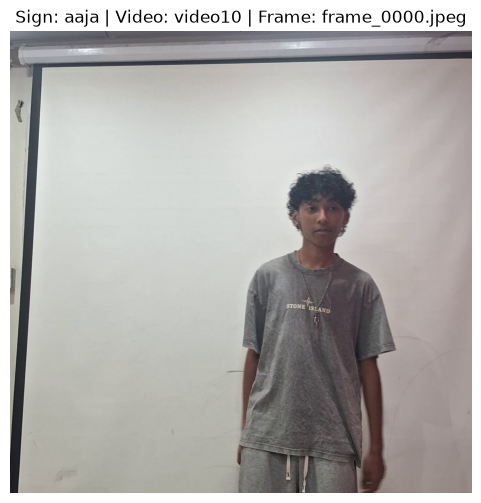

Image shape: (1440, 1440, 3)


In [13]:
import cv2
import matplotlib.pyplot as plt

# Load one frame from first video of first sign
train_path = os.path.join(dataset_path, "train")
first_sign = os.listdir(train_path)[0]
first_video = os.listdir(os.path.join(train_path, first_sign))[0]
first_frame = os.listdir(os.path.join(train_path, first_sign, first_video))[0]

frame_path = os.path.join(train_path, first_sign, first_video, first_frame)

img = cv2.imread(frame_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title(f"Sign: {first_sign} | Video: {first_video} | Frame: {first_frame}")
plt.axis('off')
plt.show()

print("Image shape:", img.shape)

In [14]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Setup Hand Landmarker
hand_base = python.BaseOptions(model_asset_path="hand_landmarker.task")
hand_options = vision.HandLandmarkerOptions(
    base_options=hand_base,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.3,
)
hand_landmarker = vision.HandLandmarker.create_from_options(hand_options)

# Setup Pose Landmarker
pose_base = python.BaseOptions(model_asset_path="pose_landmarker.task")
pose_options = vision.PoseLandmarkerOptions(
    base_options=pose_base,
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.3,
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)

# Test on first frame
mp_image = mp.Image.create_from_file(frame_path)
hand_result = hand_landmarker.detect(mp_image)
pose_result = pose_landmarker.detect(mp_image)

print(f"Hands detected: {len(hand_result.hand_landmarks)}")
print(f"Pose detected:  {len(pose_result.pose_landmarks)}")

if hand_result.hand_landmarks:
    print(f"  Hand 1 landmarks: {len(hand_result.hand_landmarks[0])}")
if pose_result.pose_landmarks:
    print(f"  Pose landmarks:   {len(pose_result.pose_landmarks[0])}")

Hands detected: 0
Pose detected:  1
  Pose landmarks:   33


In [15]:
# Try middle frames instead of first frame
train_path = os.path.join(dataset_path, "train")
first_sign = os.listdir(train_path)[0]
first_video = os.listdir(os.path.join(train_path, first_sign))[0]
frames = sorted(os.listdir(os.path.join(train_path, first_sign, first_video)))

print(f"Sign: {first_sign}")
print(f"Video: {first_video}")
print(f"Total frames: {len(frames)}")
print()

# Test frames 5, 10, 15, 20 (middle frames)
for frame_idx in [5, 10, 15, 20]:
    frame_path = os.path.join(train_path, first_sign, first_video, frames[frame_idx])
    mp_image = mp.Image.create_from_file(frame_path)
    
    hand_result = hand_landmarker.detect(mp_image)
    pose_result = pose_landmarker.detect(mp_image)
    
    print(f"Frame {frame_idx:2d} ({frames[frame_idx]}): "
          f"Hands={len(hand_result.hand_landmarks)} "
          f"Pose={len(pose_result.pose_landmarks)}")

Sign: aaja
Video: video10
Total frames: 25

Frame  5 (frame_0005.jpeg): Hands=1 Pose=1
Frame 10 (frame_0010.jpeg): Hands=2 Pose=1
Frame 15 (frame_0015.jpeg): Hands=2 Pose=1
Frame 20 (frame_0020.jpeg): Hands=2 Pose=1


In [16]:
import numpy as np

def extract_frame_landmarks(frame_path, hand_landmarker, pose_landmarker):
    """Extract hand + pose landmarks from one frame → 225 numbers"""
    
    mp_image = mp.Image.create_from_file(frame_path)
    hand_result = hand_landmarker.detect(mp_image)
    pose_result = pose_landmarker.detect(mp_image)
    
    landmarks = []
    
    # Left hand (21 points × 3 = 63)
    # Right hand (21 points × 3 = 63)
    # Total hands = 126
    
    left_hand = [0.0] * 63   # default zeros
    right_hand = [0.0] * 63  # default zeros
    
    if hand_result.hand_landmarks:
        for i, hand in enumerate(hand_result.hand_landmarks):
            handedness = hand_result.handedness[i][0].display_name
            coords = []
            for lm in hand:
                coords.extend([lm.x, lm.y, lm.z])
            if handedness == "Left":
                left_hand = coords
            else:
                right_hand = coords
    
    landmarks.extend(left_hand)
    landmarks.extend(right_hand)
    
    # Pose (33 points × 3 = 99)
    pose = [0.0] * 99  # default zeros
    if pose_result.pose_landmarks:
        coords = []
        for lm in pose_result.pose_landmarks[0]:
            coords.extend([lm.x, lm.y, lm.z])
        pose = coords
    
    landmarks.extend(pose)
    
    return np.array(landmarks)  # shape (225,)


# Test on one full video
video_path = os.path.join(train_path, first_sign, first_video)
frames = sorted(os.listdir(video_path))

sequence = []
for frame_name in frames:
    frame_path = os.path.join(video_path, frame_name)
    landmarks = extract_frame_landmarks(frame_path, hand_landmarker, pose_landmarker)
    sequence.append(landmarks)

sequence = np.array(sequence)
print(f"✅ One video extracted!")
print(f"Shape: {sequence.shape}")
print(f"Expected: (25, 225)")

✅ One video extracted!
Shape: (25, 225)
Expected: (25, 225)


In [19]:
from tqdm import tqdm

def extract_dataset(split_path, hand_landmarker, pose_landmarker):
    """Extract landmarks from all videos in a split (train/val/test)"""
    
    X = []  # sequences
    y = []  # labels
    
    signs = sorted(os.listdir(split_path))
    sign_to_idx = {sign: idx for idx, sign in enumerate(signs)}
    
    print(f"Signs: {signs}\n")
    
    for sign in signs:
        sign_path = os.path.join(split_path, sign)
        videos = sorted(os.listdir(sign_path))
        
        print(f"Processing: {sign} ({len(videos)} videos)...")
        
        for video in tqdm(videos):
            video_path = os.path.join(sign_path, video)
            frames = sorted(os.listdir(video_path))
            
            sequence = []
            for frame_name in frames:
                frame_path = os.path.join(video_path, frame_name)
                landmarks = extract_frame_landmarks(
                    frame_path, hand_landmarker, pose_landmarker
                )
                sequence.append(landmarks)
            
            if len(sequence) == 25:  # only keep complete sequences
                X.append(sequence)
                y.append(sign_to_idx[sign])
    
    return np.array(X), np.array(y), sign_to_idx

# Extract train set
print("=" * 50)
print("Extracting TRAIN set...")
print("=" * 50)
X_train, y_train, sign_to_idx = extract_dataset(
    os.path.join(dataset_path, "train"),
    hand_landmarker, pose_landmarker
)

print(f"\n✅ Train done!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Extracting TRAIN set...
Signs: ['aaja', 'aitabar', 'bal', 'behebar', 'bhat', 'bholi', 'budhabar', 'ghar', 'hami', 'hijo', 'janu', 'khanu', 'khelnu', 'kitab', 'ma', 'manglabar', 'padnu', 'sanibar', 'sombar', 'sukrabar', 'timi', 'uni']

Processing: aaja (67 videos)...


100%|██████████| 67/67 [01:49<00:00,  1.63s/it]


Processing: aitabar (68 videos)...


100%|██████████| 68/68 [01:48<00:00,  1.60s/it]


Processing: bal (67 videos)...


...

Processing: timi (68 videos)...


100%|██████████| 68/68 [01:51<00:00,  1.64s/it]


Processing: uni (67 videos)...


100%|██████████| 67/67 [01:46<00:00,  1.60s/it]


✅ Train done!
X_train shape: (1415, 25, 225)
y_train shape: (1415,)


In [20]:
# Extract val set
print("=" * 50)
print("Extracting VAL set...")
print("=" * 50)
X_val, y_val, _ = extract_dataset(
    os.path.join(dataset_path, "val"),
    hand_landmarker, pose_landmarker
)
print(f"\n✅ Val done!")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Extract test set
print("\n" + "=" * 50)
print("Extracting TEST set...")
print("=" * 50)
X_test, y_test, _ = extract_dataset(
    os.path.join(dataset_path, "test"),
    hand_landmarker, pose_landmarker
)
print(f"\n✅ Test done!")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Extracting VAL set...
Signs: ['aaja', 'aitabar', 'bal', 'behebar', 'bhat', 'bholi', 'budhabar', 'ghar', 'hami', 'hijo', 'janu', 'khanu', 'khelnu', 'kitab', 'ma', 'manglabar', 'padnu', 'sanibar', 'sombar', 'sukrabar', 'timi', 'uni']

Processing: aaja (11 videos)...


100%|██████████| 11/11 [00:17<00:00,  1.64s/it]


Processing: aitabar (11 videos)...


100%|██████████| 11/11 [00:19<00:00,  1.76s/it]


Processing: bal (11 videos)...


...

Processing: timi (19 videos)...


100%|██████████| 19/19 [00:32<00:00,  1.70s/it]


Processing: uni (19 videos)...


100%|██████████| 19/19 [00:31<00:00,  1.63s/it]


✅ Test done!
X_test shape: (395, 25, 225)
y_test shape: (395,)


In [21]:
import numpy as np

# Save all arrays
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

# Save sign labels
import json
with open("sign_to_idx.json", "w") as f:
    json.dump(sign_to_idx, f)

print("✅ All saved!")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Signs:   {sign_to_idx}")

✅ All saved!
X_train: (1415, 25, 225)
X_val:   (225, 25, 225)
X_test:  (395, 25, 225)
Signs:   {'aaja': 0, 'aitabar': 1, 'bal': 2, 'behebar': 3, 'bhat': 4, 'bholi': 5, 'budhabar': 6, 'ghar': 7, 'hami': 8, 'hijo': 9, 'janu': 10, 'khanu': 11, 'khelnu': 12, 'kitab': 13, 'ma': 14, 'manglabar': 15, 'padnu': 16, 'sanibar': 17, 'sombar': 18, 'sukrabar': 19, 'timi': 20, 'uni': 21}


✅ Model works!
Input shape:  torch.Size([4, 25, 225])
Output shape: torch.Size([4, 22])
Expected:     (4, 22)
Total parameters: 436,054


In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from model import SignLanguageTransformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15056\873676112.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


              precision    recall  f1-score   support

        aaja       0.59      0.68      0.63        19
     aitabar       0.67      0.42      0.52        19
         bal       0.41      0.47      0.44        19
     behebar       0.70      0.89      0.78        18
        bhat       0.53      0.62      0.57        16
       bholi       0.27      0.16      0.20        19
    budhabar       0.67      0.88      0.76        16
        ghar       0.88      0.79      0.83        19
        hami       0.33      0.17      0.22        18
        hijo       0.55      0.65      0.59        17
        janu       0.56      0.28      0.37        18
       khanu       0.31      0.24      0.27        17
      khelnu       0.54      0.68      0.60        19
       kitab       0.61      0.58      0.59        19
          ma       0.52      0.65      0.58        17
   manglabar       0.54      0.72      0.62        18
       padnu       0.50      0.47      0.48        17
     sanibar       0.45    

<Figure size 1400x1200 with 0 Axes>

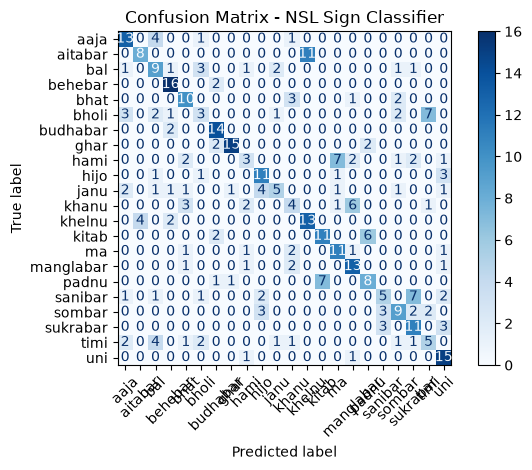

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import json

# Load sign labels
with open("sign_to_idx.json") as f:
    sign_to_idx = json.load(f)
idx_to_sign = {v: k for k, v in sign_to_idx.items()}
SIGNS = [idx_to_sign[i] for i in range(22)]

# Load test data
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.LongTensor(y_test).to(DEVICE)

# Load best model
model = SignLanguageTransformer().to(DEVICE)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Predict
with torch.no_grad():
    outputs = model(X_test_t)
    preds = outputs.argmax(1).cpu().numpy()
    true  = y_test_t.cpu().numpy()

# Report
print(classification_report(true, preds, target_names=SIGNS))

# Confusion matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SIGNS)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - NSL Sign Classifier")
plt.tight_layout()
plt.show()

In [34]:
import cv2
import torch
import numpy as np
import json
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from model import SignLanguageTransformer
from collections import deque

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load sign labels
with open("sign_to_idx.json") as f:
    sign_to_idx = json.load(f)
idx_to_sign = {v: k for k, v in sign_to_idx.items()}

# Load model
model = SignLanguageTransformer().to(DEVICE)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Setup MediaPipe
hand_base = python.BaseOptions(model_asset_path="hand_landmarker.task")
hand_options = vision.HandLandmarkerOptions(
    base_options=hand_base,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.3,
)
hand_landmarker = vision.HandLandmarker.create_from_options(hand_options)

pose_base = python.BaseOptions(model_asset_path="pose_landmarker.task")
pose_options = vision.PoseLandmarkerOptions(
    base_options=pose_base,
    running_mode=vision.RunningMode.VIDEO,
    min_pose_detection_confidence=0.3,
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)

def extract_live_landmarks(frame, hand_landmarker, pose_landmarker, timestamp):
    """Extract landmarks from one live frame"""
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

    hand_result = hand_landmarker.detect_for_video(mp_image, timestamp)
    pose_result = pose_landmarker.detect_for_video(mp_image, timestamp)

    landmarks = []

    left_hand  = [0.0] * 63
    right_hand = [0.0] * 63

    if hand_result.hand_landmarks:
        for i, hand in enumerate(hand_result.hand_landmarks):
            handedness = hand_result.handedness[i][0].display_name
            coords = []
            for lm in hand:
                coords.extend([lm.x, lm.y, lm.z])
            if handedness == "Left":
                left_hand = coords
            else:
                right_hand = coords

    landmarks.extend(left_hand)
    landmarks.extend(right_hand)

    pose = [0.0] * 99
    if pose_result.pose_landmarks:
        coords = []
        for lm in pose_result.pose_landmarks[0]:
            coords.extend([lm.x, lm.y, lm.z])
        pose = coords

    landmarks.extend(pose)

    return np.array(landmarks), hand_result, pose_result

# ── Main Loop ────────────────────────────────────────────────
cap = cv2.VideoCapture(0)
print("✅ Camera opened")
print("Perform a sign for 25 frames — prediction appears automatically")
print("Press Q to quit")

# Buffer to collect 25 frames
frame_buffer = deque(maxlen=25)
timestamp    = 0
predicted    = "Waiting for sign..."
confidence   = 0.0

CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]

while True:
    ret, frame = cap.read()
    if not ret:
        break

    timestamp += 1

    # Extract landmarks
    landmarks, hand_result, pose_result = extract_live_landmarks(
        frame, hand_landmarker, pose_landmarker, timestamp
    )

    # Add to buffer
    frame_buffer.append(landmarks)

    h, w, _ = frame.shape

    # Draw hand landmarks
    if hand_result.hand_landmarks:
        for hand in hand_result.hand_landmarks:
            for lm in hand:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)
            for s, e in CONNECTIONS:
                x1, y1 = int(hand[s].x * w), int(hand[s].y * h)
                x2, y2 = int(hand[e].x * w), int(hand[e].y * h)
                cv2.line(frame, (x1,y1), (x2,y2), (0, 0, 255), 2)

    # Draw pose landmarks
    if pose_result.pose_landmarks:
        for lm in pose_result.pose_landmarks[0]:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(frame, (cx, cy), 3, (255, 255, 0), -1)

    # Predict when buffer is full (every 25 frames)
    if len(frame_buffer) == 25 and timestamp % 25 == 0:
        sequence = np.array(list(frame_buffer))
        input_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            probs  = torch.softmax(output, dim=1)
            conf, pred_idx = torch.max(probs, dim=1)
            predicted  = idx_to_sign[pred_idx.item()]
            confidence = conf.item() * 100

    # Display
    cv2.putText(frame,
               f"Sign: {predicted}",
               (10, 40),
               cv2.FONT_HERSHEY_SIMPLEX,
               1.0, (0, 255, 0), 2)

    cv2.putText(frame,
               f"Conf: {confidence:.1f}%",
               (10, 80),
               cv2.FONT_HERSHEY_SIMPLEX,
               0.8, (0, 255, 255), 2)

    cv2.putText(frame,
               f"Frames: {len(frame_buffer)}/25",
               (10, 120),
               cv2.FONT_HERSHEY_SIMPLEX,
               0.8, (255, 255, 255), 2)

    cv2.imshow("NSL Sign Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
hand_landmarker.close()
pose_landmarker.close()
print("✅ Done")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15056\678787189.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


✅ Camera opened
Perform a sign for 25 frames — prediction appears automatically
Press Q to quit
✅ Done
